<a href="https://colab.research.google.com/github/vishnu1234555/ML/blob/main/House_pricing_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import zipfile

zip_file_path = '/content/house-prices-advanced-regression-techniques.zip'


with zipfile.ZipFile(zip_file_path, 'r') as z:
    with z.open('train.csv') as f:
        train_data = pd.read_csv(f)

print("Extraction complete. Data loaded.")

Extraction complete. Data loaded.


In [8]:
"""
Data Ingestion and Quality Assessment Module.
Analyzes the Ames Housing dataset for dimensionality and structural integrity.
"""
import pandas as pd
import logging

# Professionals use logging, not just print statements, to track pipeline execution
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def assess_data_quality(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates the total and percentage of missing values per column.

    Args:
        df (pd.DataFrame): The raw data frame.

    Returns:
        pd.DataFrame: A summary of missing data sorted by severity.
    """
    logging.info(f"Assessing dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100

    missing_df = pd.DataFrame({
        'Total_Missing': missing_count,
        'Percentage': missing_percent
    })

    # Filter for columns with missing data and sort
    missing_df = missing_df[missing_df['Total_Missing'] > 0].sort_values(by='Total_Missing', ascending=False)

    return missing_df

# Execute the function using the data you just extracted from the ZIP
missing_report = assess_data_quality(train_data)

print("\n--- CRITICAL MISSING DATA REPORT ---")
print(missing_report.head(10))


--- CRITICAL MISSING DATA REPORT ---
              Total_Missing  Percentage
PoolQC                 1453   99.520548
MiscFeature            1406   96.301370
Alley                  1369   93.767123
Fence                  1179   80.753425
MasVnrType              872   59.726027
FireplaceQu             690   47.260274
LotFrontage             259   17.739726
GarageType               81    5.547945
GarageYrBlt              81    5.547945
GarageFinish             81    5.547945


In [9]:
"""
Feature Imputation Pipeline.
Systematically resolves missing values using structural logic and statistical measures.
"""

def run_imputation_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """
    Main execution hook for data cleaning.

    Args:
        df (pd.DataFrame): The raw training data.

    Returns:
        pd.DataFrame: A dataset with 0 missing values.
    """
    df_clean = df.copy()

    # 1. Structural 'None' (Features that don't exist)
    # These columns represent luxuries; if NaN, the house simply doesn't have them.
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']
    for col in none_cols:
        df_clean[col] = df_clean[col].fillna('None')

    # 2. Neighborhood-Based Imputation
    # LotFrontage is logically tied to the specific street/area.
    logging.info("Applying neighborhood-median imputation to LotFrontage.")
    df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

    # 3. Garage & Basement - Structural Zeroes & None
    # If the feature doesn't exist, the area is 0 and the quality is 'None'.
    logging.info("Cleaning Garage and Basement structural data.")

    # Numerical fixes
    num_struct_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
                       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
    for col in num_struct_cols:
        df_clean[col] = df_clean[col].fillna(0)

    # Categorical fixes
    cat_struct_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
    for col in cat_struct_cols:
        df_clean[col] = df_clean[col].fillna('None')

    # 4. Final Clerical Cleanup (Mode/Median for random isolated NaNs)
    # This captures the remaining 1-2 row errors in random columns.
    logging.info("Resolving remaining isolated missing values.")

    # Categorical: use most frequent (mode)
    for col in df_clean.select_dtypes(include=['object']).columns:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    # Numerical: use outlier-resistant median
    for col in df_clean.select_dtypes(exclude=['object']).columns:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    logging.info("Imputation complete. Data is 100% clean.")
    return df_clean

# EXECUTION
train_data_clean = run_imputation_pipeline(train_data)

# VERIFICATION
remaining_nans = train_data_clean.isnull().sum().sum()
print(f"\nFinal NaN count: {remaining_nans}")


Final NaN count: 0


In [10]:
"""
Feature Encoding Module.
Converts categorical text data into numerical vectors for model ingestion.
"""

def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Applies One-Hot Encoding to all categorical columns.

    Args:
        df (pd.DataFrame): The cleaned data frame.

    Returns:
        pd.DataFrame: A data frame containing only numerical values.
    """
    logging.info("Starting One-Hot Encoding for all categorical variables.")

    # This pandas function automatically identifies 'object' columns
    # and converts them into binary (0 or 1) columns.
    df_encoded = pd.get_dummies(df)

    logging.info(f"Encoding complete. New shape: {df_encoded.shape}")
    return df_encoded

# EXECUTION
# We drop 'Id' because it's a random serial number and will confuse the model
train_final = encode_features(train_data_clean.drop(columns=['Id']))

print("\n--- FIRST 5 ROWS OF NUMERICAL DATA ---")
print(train_final.head())


--- FIRST 5 ROWS OF NUMERICAL DATA ---
   MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0          60         65.0     8450            7            5       2003   
1          20         80.0     9600            6            8       1976   
2          60         68.0    11250            7            5       2001   
3          70         60.0     9550            7            5       1915   
4          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  SaleType_ConLw  \
0          2003       196.0         706           0  ...           False   
1          1976         0.0         978           0  ...           False   
2          2002       162.0         486           0  ...           False   
3          1970         0.0         216           0  ...           False   
4          2000       350.0         655           0  ...           False   

   SaleType_New  SaleType_Oth  SaleType_WD  Sa

In [11]:
"""
Data Splitting Module.
Partitioning the dataset into features (X) and target (y), followed by a validation split.
"""
from sklearn.model_selection import train_test_split
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def prepare_training_sets(df: pd.DataFrame, target_col: str):
    """
    Separates target from features and performs an 80/20 train-test split.

    Args:
        df (pd.DataFrame): The fully encoded, numerical dataframe.
        target_col (str): The name of the column to predict.

    Returns:
        tuple: (X_train, X_val, y_train, y_val)
    """
    logging.info(f"Separating target variable: {target_col}")

    # 1. Define X (Features) and y (Target)
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # 2. Perform the Split
    # random_state=42 ensures your results are reproducible (the "seed")
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    logging.info(f"Split complete. Training rows: {len(X_train)} | Validation rows: {len(X_val)}")
    return X_train, X_val, y_train, y_val

# EXECUTION
X_train, X_val, y_train, y_val = prepare_training_sets(train_final, 'SalePrice')

print("\n--- DATA READY FOR MODELING ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


--- DATA READY FOR MODELING ---
X_train shape: (1168, 301)
y_train shape: (1168,)


In [12]:
"""
Model Training and Evaluation Module.
Implements a Random Forest baseline and calculates error metrics.
"""
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import logging

def train_and_evaluate(X_train, X_val, y_train, y_val) -> RandomForestRegressor:
    """
    Trains a Random Forest model and evaluates performance on the validation set.
    """
    logging.info("Initializing Random Forest Regressor training...")

    # 1. Initialize the Model
    # n_estimators=100 means we are building 100 different trees
    model = RandomForestRegressor(n_estimators=100, random_state=42)

    # 2. Train (Fit) the model
    model.fit(X_train, y_train)
    logging.info("Training complete.")

    # 3. Predict on validation data
    predictions = model.predict(X_val)

    # 4. Calculate the Error (In actual Dollars)
    mae = mean_absolute_error(y_val, predictions)

    print("\n--- MODEL PERFORMANCE REPORT ---")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")

    return model

# EXECUTION
baseline_model = train_and_evaluate(X_train, X_val, y_train, y_val)


--- MODEL PERFORMANCE REPORT ---
Mean Absolute Error (MAE): $17,446.53


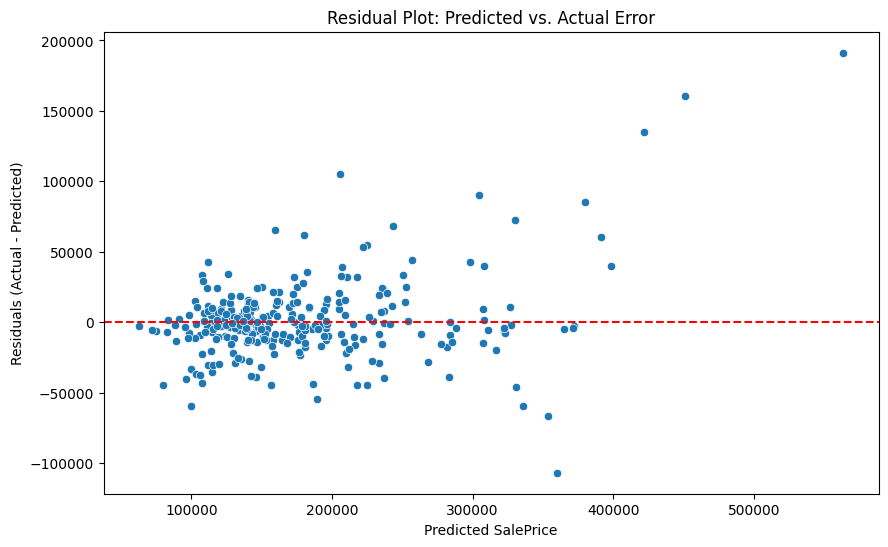

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import logging

def perform_model_diagnostics(y_val, y_pred):
    """
    Calculates R2 and plots residuals to check for heteroscedasticity.
    """
    r2 = r2_score(y_val, y_pred)
    residuals = y_val - y_pred

    logging.info(f"Model R2 Score: {r2:.4f}")

    # Visualization
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residual Plot: Predicted vs. Actual Error')
    plt.xlabel('Predicted SalePrice')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.show()

    return r2

# EXECUTION
predictions = baseline_model.predict(X_val)
r2_val = perform_model_diagnostics(y_val, predictions)

In [15]:
"""
Advanced Target Transformation Module.
Applies Log-Transformation to the target variable to resolve heteroscedasticity.
"""
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. Apply the Log Transformation to the Target
y_log = np.log1p(train_final['SalePrice'])
X = train_final.drop(columns=['SalePrice'])

# 2. Re-Split the data with the transformed target
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 3. Re-Train the baseline model
logging.info("Training model on Log-Transformed target...")
log_model = RandomForestRegressor(n_estimators=100, random_state=42)
log_model.fit(X_train, y_train_log)

# 4. Predict and Transform BACK to actual dollars
log_preds = log_model.predict(X_val)
final_preds = np.expm1(log_preds) # Inverse of log1p
actual_prices = np.expm1(y_val_log)

# 5. Check the new MAE
new_mae = mean_absolute_error(actual_prices, final_preds)

print(f"\n--- LOG-TRANSFORMED RESULTS ---")
print(f"Old MAE: $17,446.53")
print(f"New MAE: ${new_mae:,.2f}")


--- LOG-TRANSFORMED RESULTS ---
Old MAE: $17,446.53
New MAE: $17,470.06


/tmp/ipykernel_1197/1014499175.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


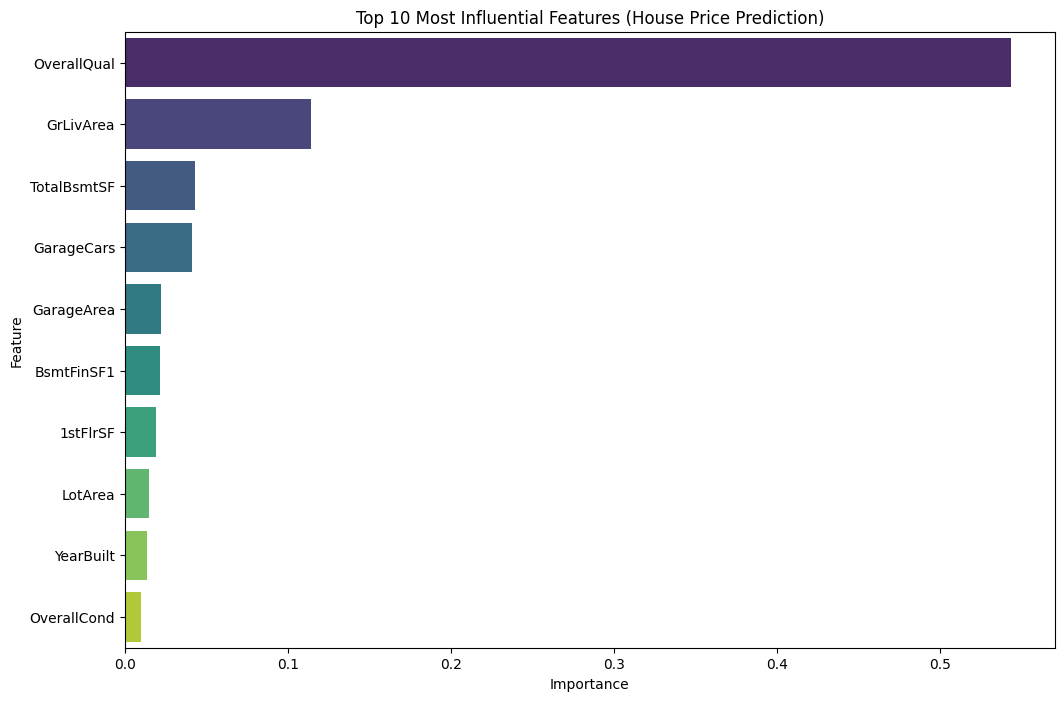


--- TOP 5 PRICE DRIVERS ---
        Feature  Importance
3   OverallQual    0.543499
15    GrLivArea    0.113941
11  TotalBsmtSF    0.043174
25   GarageCars    0.040933
26   GarageArea    0.022065


In [16]:
"""
Feature Importance Analysis Module.
Identifies and visualizes the primary drivers of the predictive model.
"""
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, features):
    """
    Extracts and plots the top 10 most influential features.
    """
    # 1. Extract importance scores
    importances = model.feature_importances_
    feature_names = features.columns

    # 2. Create a DataFrame for easy sorting
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # 3. Plot the Top 10
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
    plt.title('Top 10 Most Influential Features (House Price Prediction)')
    plt.show()

    return feature_importance_df

# EXECUTION
# Note: Use the model and features from your best performing run
importance_results = plot_feature_importance(log_model, X_train)

# Show the raw numbers for the top 5
print("\n--- TOP 5 PRICE DRIVERS ---")
print(importance_results.head(5))

In [17]:
"""
Feature Pruning and Model Optimization Module.
Reduces dimensionality by retaining only high-impact features to combat overfitting.
"""
import logging

def prune_and_retrain(X_train, X_val, y_train, y_val, importance_df, top_n=30):
    """
    Filters the dataset for the Top N features and re-evaluates the baseline.
    """
    # 1. Identify the high-performers
    top_features = importance_df.head(top_n)['Feature'].tolist()
    logging.info(f"Pruning dataset. Retaining top {top_n} features out of {X_train.shape[1]}.")

    # 2. Subset the data
    X_train_pruned = X_train[top_features]
    X_val_pruned = X_val[top_features]

    # 3. Retrain the baseline
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_pruned, y_train)

    # 4. Evaluate
    preds = model.predict(X_val_pruned)
    # Using np.expm1 if you are still using the log-transformed target
    mae = mean_absolute_error(np.expm1(y_val), np.expm1(preds))

    logging.info(f"Pruned Model MAE: ${mae:,.2f}")
    return model, X_train_pruned, X_val_pruned

# EXECUTION
pruned_model, X_train_p, X_val_p = prune_and_retrain(
    X_train, X_val, y_train_log, y_val_log, importance_results, top_n=30
)

In [18]:
"""
Gradient Boosting Optimization Module.
Implements XGBoost Regressor to minimize residual error through sequential learning.
"""
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import logging

def train_xgboost(X_train, X_val, y_train, y_val):
    """
    Trains an XGBoost model and evaluates performance on the validation set.
    """
    logging.info("Initializing XGBoost Regressor...")

    # These are 'standard' high-performance hyperparameters
    # n_estimators: Number of trees
    # learning_rate: How much we trust each new tree (Eta)
    # max_depth: How complex each tree can be
    xgb_model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1 # Use all CPU cores
    )

    # Training
    logging.info("Training XGBoost...")
    xgb_model.fit(X_train, y_train)

    # Prediction
    preds_log = xgb_model.predict(X_val)

    # Inverse transform to get actual dollar amounts
    final_preds = np.expm1(preds_log)
    actual_prices = np.expm1(y_val)

    mae = mean_absolute_error(actual_prices, final_preds)

    logging.info(f"XGBoost MAE: ${mae:,.2f}")
    return xgb_model, mae

# EXECUTION (Using your pruned Top 30 features)
xgb_model, xgb_mae = train_xgboost(X_train_p, X_val_p, y_train_log, y_val_log)

In [19]:
"""
Hyperparameter Optimization Module.
Utilizes RandomizedSearchCV to find the optimal configuration for the XGBoost Regressor.
"""
from sklearn.model_selection import RandomizedSearchCV
import logging

def optimize_xgboost(X_train, y_train):
    """
    Performs a randomized search over a defined hyperparameter space.
    """
    logging.info("Starting Hyperparameter Optimization...")

    # 1. Define the 'Search Space' (The ranges for our knobs)
    param_grid = {
        'n_estimators': [500, 1000, 1500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5, 6],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    }

    # 2. Initialize the search
    # cv=5 means it will split the data 5 times to ensure the score is stable
    # n_iter=10 means it will try 10 random combinations
    search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42),
        param_distributions=param_grid,
        n_iter=10,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1,
        random_state=42
    )

    # 3. Execute the search
    search.fit(X_train, y_train)

    logging.info(f"Optimization complete. Best Params: {search.best_params_}")
    return search.best_estimator_

# EXECUTION
best_xgb_model = optimize_xgboost(X_train_p, y_train_log)

# Final Evaluation
best_preds_log = best_xgb_model.predict(X_val_p)
final_best_preds = np.expm1(best_preds_log)
final_mae = mean_absolute_error(np.expm1(y_val_log), final_best_preds)

print(f"\n--- OPTIMIZED MODEL PERFORMANCE ---")
print(f"Previous XGBoost MAE: ${xgb_mae:,.2f}")
print(f"Tuned XGBoost MAE: ${final_mae:,.2f}")


--- OPTIMIZED MODEL PERFORMANCE ---
Previous XGBoost MAE: $17,037.05
Tuned XGBoost MAE: $16,512.76


In [20]:
"""
Feature Engineering Module.
Creates domain-specific interaction variables to capture complex property value drivers.
"""
import logging

def engineer_house_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Constructs high-signal features by combining related low-signal variables.
    """
    df_eng = df.copy()

    logging.info("Engineering interaction features...")

    # 1. Total Square Footage: The single most important driver for buyers
    df_eng['TotalSF'] = df_eng['TotalBsmtSF'] + df_eng['1stFlrSF'] + df_eng['2ndFlrSF']

    # 2. Total Bathrooms: Combining split counts into a human-readable metric
    df_eng['TotalBathrooms'] = (df_eng['FullBath'] + (0.5 * df_eng['HalfBath']) +
                                df_eng['BsmtFullBath'] + (0.5 * df_eng['BsmtHalfBath']))

    # 3. Property Age: Newer houses have higher baseline values (Current Year = 2026)
    df_eng['HouseAge'] = 2026 - df_eng['YearBuilt']
    df_eng['YearsSinceRemod'] = 2026 - df_eng['YearRemodAdd']

    # 4. Total Porch Area: Luxury features tend to cluster
    df_eng['TotalPorchSF'] = (df_eng['OpenPorchSF'] + df_eng['3SsnPorch'] +
                              df_eng['EnclosedPorch'] + df_eng['ScreenPorch'] +
                              df_eng['WoodDeckSF'])

    # 5. Quality-Space Interaction: A large house is only valuable if it's high quality
    df_eng['Qual_x_SF'] = df_eng['OverallQual'] * df_eng['TotalSF']

    logging.info(f"Feature engineering complete. New features added.")
    return df_eng

# EXECUTION
train_data_engineered = engineer_house_features(train_data_clean)

In [22]:
def run_final_evaluation(df_engineered: pd.DataFrame, best_params: dict):
    """
    Re-encodes, splits, and trains the optimized model on engineered features.
    """
    logging.info("Starting final pipeline execution...")

    # 1. Re-encode
    df_final = pd.get_dummies(df_engineered.drop(columns=['Id']))

    # 2. Re-split with the log-transformed target
    y_log = np.log1p(df_final['SalePrice'])
    X = df_final.drop(columns=['SalePrice'])

    X_train, X_val, y_train, y_val = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    # 3. Train with UNPACKED parameters only
    # The ** operator unpacks the dictionary into keyword arguments.
    logging.info("Training optimized XGBoost on engineered features...")
    final_model = xgb.XGBRegressor(**best_params)
    final_model.fit(X_train, y_train)

    # 4. Final Prediction & Inverse Transform
    preds_log = final_model.predict(X_val)
    final_preds = np.expm1(preds_log)
    actual_prices = np.expm1(y_val)

    mae = mean_absolute_error(actual_prices, final_preds)

    logging.info(f"FINAL ENGINEERED MAE: ${mae:,.2f}")
    return final_model, X, mae

In [24]:
"""
Final Model Integration Module.
Re-processes engineered data through the encoding and training pipeline.
"""
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import logging

def run_final_evaluation(df_engineered: pd.DataFrame, best_params: dict):
    """
    Re-encodes, splits, and trains the optimized model on engineered features.
    """
    logging.info("Starting final pipeline execution...")

    # 1. Re-encode (Include the new engineered numerical features)
    df_final = pd.get_dummies(df_engineered.drop(columns=['Id']))

    # 2. Re-split with the log-transformed target
    y_log = np.log1p(df_final['SalePrice'])
    X = df_final.drop(columns=['SalePrice'])

    X_train, X_val, y_train, y_val = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    # 3. Train with the BEST parameters found during your search
    # The ** operator unpacks the best_params dictionary automatically
    logging.info("Training optimized XGBoost on engineered features...")
    final_model = xgb.XGBRegressor(**best_params)
    final_model.fit(X_train, y_train)

    # 4. Final Prediction & Inverse Transform
    preds_log = final_model.predict(X_val)
    final_preds = np.expm1(preds_log)
    actual_prices = np.expm1(y_val)

    mae = mean_absolute_error(actual_prices, final_preds)

    logging.info(f"FINAL ENGINEERED MAE: ${mae:,.2f}")
    return final_model, X, mae

# EXECUTION
# Ensure 'best_xgb_model' was successfully created in your previous search cell
best_params_dict = best_xgb_model.get_params()
final_model, X_final_cols, final_mae = run_final_evaluation(train_data_engineered, best_params_dict)

In [25]:
final_mae

14763.933219178092